In [5]:
# Import the Pandas file
import pandas as pd

# Read the csv file
df = pd.read_csv("telecom_customer_churn_analysis.csv")
df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


Understand The Dataset

In [6]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


Check Missing Values

In [7]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Age,0
Married,0
Number of Dependents,0
City,0
Zip Code,0
Latitude,0
Longitude,0
Number of Referrals,0


Check Churn Distribution

In [8]:
df['Customer Status'].value_counts()

,count
Customer Status,
Stayed,4720
Churned,1869
Joined,454


Churn by contract type

In [9]:
df.groupby('Contract')['Customer Status'].value_counts()

Contract        Customer Status
Month-to-Month  Churned            1655
                Stayed             1547
                Joined              408
One Year        Stayed             1360
                Churned             166
                Joined               24
Two Year        Stayed             1813
                Churned              48
                Joined               22
Name: count, dtype: int64

Churn by Payment Method

In [10]:
df.groupby('Payment Method')['Customer Status'].value_counts()

Payment Method   Customer Status
Bank Withdrawal  Stayed             2399
                 Churned            1329
                 Joined              181
Credit Card      Stayed             2120
                 Churned             398
                 Joined              231
Mailed Check     Stayed              201
                 Churned             142
                 Joined               42
Name: count, dtype: int64

Churn by Internet Type

In [11]:
df.groupby('Internet Type')['Customer Status'].value_counts()

Internet Type  Customer Status
Cable          Stayed              561
               Churned             213
               Joined               56
DSL            Stayed             1230
               Churned             307
               Joined              115
Fiber Optic    Stayed             1698
               Churned            1236
               Joined              101
Name: count, dtype: int64

What are the Top Churn reasons?

In [12]:
df['Churn Reason'].value_counts().head(10)

,count
Churn Reason,
Competitor had better devices,313
Competitor made better offer,311
Attitude of support person,220
Don't know,130
Competitor offered more data,117
Competitor offered higher download speeds,100
Attitude of service provider,94
Price too high,78
Product dissatisfaction,77


Correlation

In [13]:
df.corr(numeric_only=True)

,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
Age,1.000000,-0.119000,-0.008183,-0.010305,0.007612,-0.025141,0.009927,-0.020010,-0.566518,0.134511,0.059684,0.024168,0.025036,0.003065,0.048265
Number of Dependents,-0.119000,1.000000,0.016493,0.029081,-0.024271,0.278003,0.108237,-0.002898,0.300802,-0.125649,0.022535,0.014023,-0.014436,0.068966,0.038038
Zip Code,-0.008183,0.016493,1.000000,0.894769,-0.790564,0.001463,0.007146,0.012298,-0.002859,-0.002517,0.001978,-0.003797,-0.014550,0.005063,0.002944
Latitude,-0.010305,0.029081,0.894769,1.000000,-0.885979,0.018715,0.011963,0.014450,-0.013485,-0.021613,-0.002784,-0.009901,-0.013233,0.008029,0.000082
Longitude,0.007612,-0.024271,-0.790564,-0.885979,1.000000,-0.009893,-0.009672,-0.015420,0.015195,0.021052,0.003811,-0.000597,0.010461,-0.006923,0.001062
Number of Referrals,-0.025141,0.278003,0.001463,0.018715,-0.009893,1.000000,0.326975,0.001800,0.080243,0.026301,0.250378,0.024756,0.000350,0.216190,0.261853
Tenure in Months,0.009927,0.108237,0.007146,0.011963,-0.009672,0.326975,1.000000,0.012713,0.038173,0.239065,0.826074,0.059021,0.082266,0.674149,0.853146
Avg Monthly Long Distance Charges,-0.020010,-0.002898,0.012298,0.014450,-0.015420,0.001800,0.012713,1.000000,0.019047,0.019149,0.016946,-0.026072,0.021162,0.548759,0.173072
Avg Monthly GB Download,-0.566518,0.300802,-0.002859,-0.013485,0.015195,0.080243,0.038173,0.019047,1.000000,-0.017283,0.031957,-0.011000,0.015451,0.024101,0.031922
Monthly Charge,0.134511,-0.125649,-0.002517,-0.021613,0.021052,0.026301,0.239065,0.019149,-0.017283,1.000000,0.622810,0.023963,0.121238,0.235685,0.563249


Visualizations For Telecom Customer Churn Analysis

Import seaborn and metaplot libaries

In [14]:
import seaborn as sns

In [15]:
import matplotlib.pyplot as plt

Churn Distribution

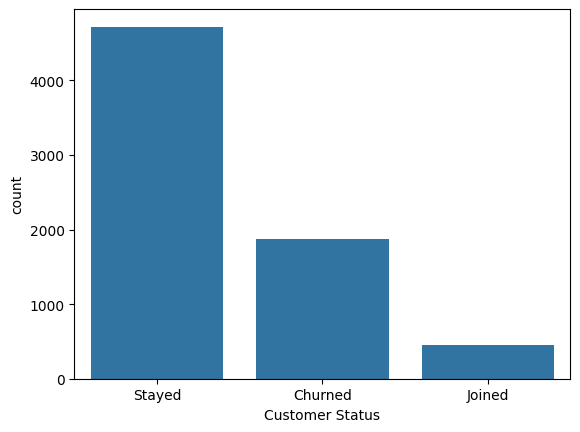

In [16]:
sns.countplot(x='Customer Status', data=df)
plt.show()

Churn By Contract

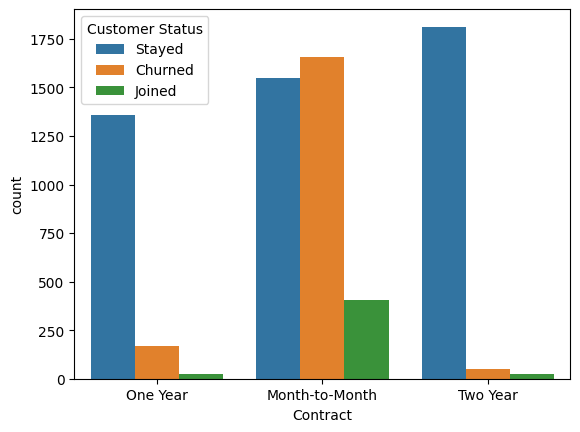

In [17]:
sns.countplot(x='Contract', hue='Customer Status', data=df)
plt.show()

Monthly Charges vs Churn

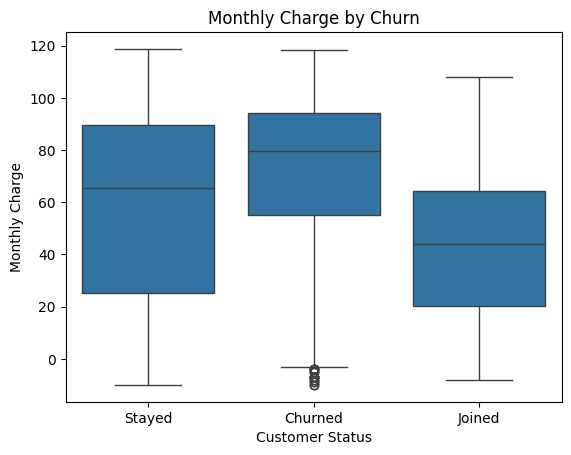

In [18]:
sns.boxplot(x='Customer Status', y='Monthly Charge', data=df)
plt.title('Monthly Charge by Churn')
plt.show()